In this notebook we recreate the plots that were presented in 'Cosmological perturbations with ultralight vector dark matter fields: numerical implementation in CLASS'.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.interpolate import interp1d

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

### LCDM

In [2]:
# Planck 2018  Cosmological parameters

h_planck = 0.6688              # TT,TE,EE+lowE
omega_m = 0.321*h_planck**2   # TT,TE,EE+lowE
omega_cdm = 0.1206            # TT,TE,EE+lowE
Omega_Lambda = 0.679          # TT,TE,EE+lowE
omega_b = 0.02212              # TT,TE,EE+lowE
tau_reio = 0.05522              # TT,TE,EE+lowE
As = 2.092 * 1.e-9             # TT,TE,EE+lowE
ns = 0.962                    # TT,TE,EE+lowE
theta_s = 1.04077              # TT,TE,EE+lowE


In [3]:
# Common settings and LCDM
colors = plt.cm.jet(np.linspace(0., 0.48, 4))#['slateblue','tomato','darkseagreen','orchid','darkslategrey']
colors = ['#3C536D', '#DAC746', '#3390D7', "#52DC46", '#DC4D57', '#8E5DD9']
#colors = ['#828D3A', '#B17918', '#899E79', '#B0705F']
masses =  [1.e-25, 1.e-24, 1.e-23, 1.e-22, 1.e-20] # eV
masses_Mpc = [mass*1.56373846613383*1.e29 for mass in masses]# Mpc^-1

precision_settings = {
    'tol_thermo_integration': 1.0e-6,
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-7,
    'k_per_decade_primordial': 30.0,
}

lcdm = Class()
lcdm_settings = {'omega_b':omega_b,'Omega_cdm' : omega_cdm/h_planck**2,'100*theta_s': theta_s,'A_s' : As
                 ,'n_s':ns,'tau_reio':tau_reio,
                 'YHe': 'BBN','output':'tCl mPk dTk vTk','gauge':'synchronous',
                 'P_k_max_h/Mpc':100.0, 'format': 'camb', 'ic' : 'ad','P_k_ini type' : 'analytic_Pk',
                 'Omega_k' : 0., 'N_ncdm' : 0}
lcdm.set(lcdm_settings)

lcdm.compute()
all_k_lcdm = lcdm.get_perturbations()
background_lcdm = lcdm.get_background()

frac = 1-1.e-6
common_settings  = {
            '100*theta_s': theta_s,
            'omega_b' : omega_b,
            'Omega_cdm' : omega_cdm*(1-frac)/h_planck**2,
            'Omega_dcdmdr' : 0.0,
            'N_ncdm' : 0,
            'Omega_k' : 0.,
            'Omega_fld' : 0.,
            'Omega_scf' : frac*omega_cdm/h_planck**2,
            'attractor_ic_scf' : 'yes',
            'scf_tuning_index' : 3,
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'output' : 'tCl mPk dTk vTk',
            'ic' : 'ad',
            'gauge' : 'synchronous',
            'P_k_ini type' : 'analytic_Pk',
            'A_s' : As,
            'n_s' : ns,
            'P_k_max_h/Mpc':100.0,
            'format': 'camb'
            } 
common_settings.update(precision_settings) 

As a benchmark, let's define the LCDM cosmology.

In [4]:
cosmo0 = {}
for m in range(len(masses)):

    cosmo0[m] = Class()
    cosmo0[m].set(common_settings)
    cosmo0[m].set({'scf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%masses[m]})
    cosmo0[m].compute()

    print(masses[m])

1e-25
1e-24
1e-23
1e-22
1e-20


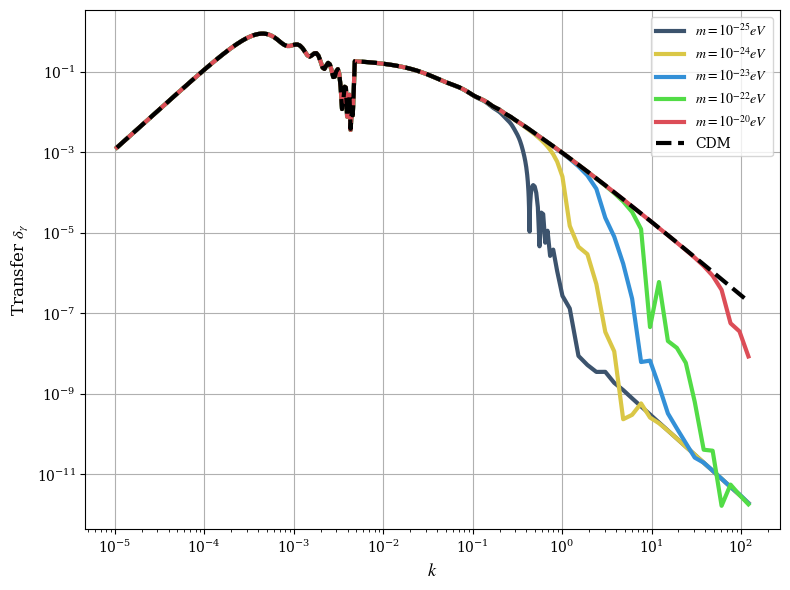

In [5]:
plt.figure(figsize=(8, 6))
for m in range(len(masses)):

    transfer = cosmo0[m].get_transfer()
    transfer_lcdm = lcdm.get_transfer()

    kk = transfer['k (h/Mpc)']
    transfer_g = transfer['d_g']
    transfer_g_lcdm = transfer_lcdm['d_g']
    transfer_psi = transfer['psi']
    
    filename = '../../SFDM_data/Transfers_sfdm/Transfer_dg_sfdm_m=10^{%s}eV' % str(masses[m])[-3:]
    
    np.savez(filename, k = kk, transfer_dg = transfer_g, transfer_psi=transfer_psi)

    plt.figure(1)
    plt.loglog(kk, np.abs(transfer_g), color=colors[m], label=r'$m=10^{%s}eV$'% str(masses[m])[-3:], lw=3)
    plt.ylabel(r"Transfer $\delta_{\gamma}$", size=12)
    plt.xlabel(r'$k$', size=13)

    if masses[m] == masses[-1]:
        plt.loglog(kk, np.abs(transfer_g_lcdm), 'k--', label=r'CDM', lw=3)
        plt.grid()
        plt.legend()
        plt.tight_layout()